# EXPLORATORY DATA ANALYSIS OF THE PIMA INDIANS DIABETES DATASET
## 1.0 Introduction
The Pima Indians Diabetes dataset is a widely used medical dataset originally compiled by the National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK). It contains diagnostic measurements used to assess the presence or absence of diabetes in adult female patients of Pima Indian heritage. The dataset is commonly used in biomedical data science due to its mix of physiological, metabolic, and demographic variables.

### 1.1 Objective
The goal of this analysis is to:
1. Examine the distribution and central tendencies of each variable
2. Identify data quality issues such as missing values, zero-value encoding, and outliers
3. Understand the feature distributions
3. Explore the relationships between clinical variables and diabetes outcome
4. Assess multivariate consistency and physiological plausibility of observed patterns

The analysis is structured into univariate analysis and bivariate correlation analysis to ensure clinical and statistical interpretation before modelling.

### 1.2 Dataset Overview
The dataset contains medical diagnostic measurements including glucose level, blood pressure, skin thickness, insulin, BMI, and diabetes outcome used to create binary outcome classifications for predicting diabetes in females of Pima Indian heritage.  
- Dataset: Pima Indians Diabetes Dataset  
- Source: National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK)
- Number of observations: 768  
- Number of features: 9 (8 predictors, 1 target variable)
- Target variable: Outcome - 0 (non-diabetic), 1 (diabetic)  

#### 1.2.1 Feature Description
- Pregnancies: Number of pregnancies  
- Glucose: Plasma glucose concentration measured  
- Blood Pressure: Diastolic Blood Pressure  
- Skin Thickness: Triceps skin fold Thickness  
- Insulin: 2-hour serum Insulin  
- BMI: Body Mass Index  
- Diabetes Pedigree Function: Genetic diabetes score using family history  
- Age: Age in years  
- Outcome: Diabetes diagnosis (binary classification)  


## 2.0 Data Loading and Inspection
Loading the dataset and performing initial inspection to understand its structure, data types, and basic statistical properties.

Importing necessary libraries.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Refining visualization characteristics

In [3]:
sns.set_theme(style="whitegrid", palette="muted")

Reading the CSV file into a DataFrame (df), using Pandas.

In [4]:
df = pd.read_csv("../data/diabetes.csv")

Inspecting the structure of the dataset, data types, missing values, and summary statistics.

In [5]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
df.tail(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [7]:
df.shape

(768, 9)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3.0 Data Quality Assessment
No null values were observed throughout the dataset, however, variables like Glucose, Blood pressure, Skin thickness, Insulin, and BMI display physiologically impossible values of zero indicating their likely use as a missing value placeholder.

Variables that are physiologically impossible to have measurements of zero:
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI

Variables that should not have zero values according to dataset description:
- Age (minimum age = 21)

Variables where zero is realistic:
- Pregnancies
- Diabetes Pedigree Function
- Outcome (binary classification: 0/1)

**Limitation:**
There is uncertainty on whether zero values in plausible variables like Pregnancies are truly zero or also placeholders.
It is only possible to convert variables Glucose, Blood Pressure, Skin Thickness, Insulin and BMI to missing (NaN) because of the physiological impossibility for the values to be zero. Variables like Pregnancies, Outcomes, and DPF will be left as is because zeros are possible.

Some variables exhibit large ranges and potential high-end outliers suggestive of skewed distributions within the dataset, however, the presence of physiologically impossible zeros may influence summary statistics prior to data cleaning.


### 3.1 Handling Missing Values
Replacing zero values in Glucose, Blood Pressure, Skin Thickness, Insulin and BMI with NaN.

In [10]:
physiological_variables = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[physiological_variables] = df[physiological_variables].replace(0, np.nan)

df[physiological_variables]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148.0,72.0,35.0,NaN,33.6
1,85.0,66.0,29.0,NaN,26.6
2,183.0,64.0,NaN,NaN,23.3
3,89.0,66.0,23.0,94.0,28.1
4,137.0,40.0,35.0,168.0,43.1
...,...,...,...,...,...
763,101.0,76.0,48.0,180.0,32.9
764,122.0,70.0,27.0,NaN,36.8
765,121.0,72.0,23.0,112.0,26.2
766,126.0,60.0,NaN,NaN,30.1


### 3.2 Checking for changes in data types and missing counts

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


### 3.3 Checking for duplicate rows

In [12]:
df.duplicated().sum()

np.int64(0)

no duplicate rows detected

## 4.0 Summary Statistics
Overview of summary statistics for each feature

In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Overall, most variables are observed to exhibit mean values greater than their median values, with variables like Blood Pressure, Skin Thickness and BMI displaying near symmetry while others displayed a mild to moderate right-skewness. Insulin however, demonstrated the strongest skew with a maximum value substantially exceeding the median.

## 5.0 Preprocessing Strategy
Checking the number of zeros and missing values per variable to guide preprocessing decisions.

In [14]:
#Confirming if zeros still present in selected columns
physiological_variables = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
(df[physiological_variables] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [15]:
#Checking number of missing values in the dataset
print("Number of missing values in dataset")
df.isna().sum()

Number of missing values in dataset


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Skin Thickness and Insulin display a high number of missing values relative to the number of entries in the dataset  
Skin Thickness - 227 out of 768  
Insulin - 374 out of 768


In [16]:
print('Percentage of missing Skin Thickness entries:', (227/768)*100)
print('Percentage of missing Insulin entries:', (374/768)*100)


Percentage of missing Skin Thickness entries: 29.557291666666668
Percentage of missing Insulin entries: 48.69791666666667


Approximately 30% of Skin Thickness and 49% of Insulin values are missing in the dataset.

Mean values may be less reliable as replacements in this case as it might significantly distort distribution and reduce variability, particularly for vital diabetes-related variables like Insulin, where a substantial portion of the values are missing. Alternatives like median would be more robust, as they are less sensitive to outliers and skewness, but may not be most effective at preserving relationships between variables.

Further exploratory analysis is still required to assess mode of missingness, including whether missingness is consistent with Missing Completely at Random (MCAR) assumption, helping to guide the selection of appropriate imputation strategies.

There are three possible reasons for missing values:
1. Missing Completely At Random (MCAR) - missingness is completely by chance and unrelated to any observed or unobserved data.
2. Missing At Random (MAR) - missingness depends on observed variables in the dataset.
3. Missing not at random (MNAR) - missingness depends on the unobserved value itself.


While MCAR can be investigated by assessing whether missingness appears random and unrelated to other variables, MAR can be explored by examining correlations/relationships between the missing values and observed variables. However, MNAR is generally not directly testable and likely requires domain knowledge or external assumptions to justify.

### 5.1 Assessing missingness overlap between Insulin and Skin Thickness variables
Skin Thickness and Insulin were prioritized for further missingness analysis due to their substantially higher proportion of missing values relative to other variables.

#### 5.1.1 Subset of observations with both Insulin and Skin Thickness values missing.

In [17]:
skin_na_insulin_na = df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna())]
skin_na_insulin_na.shape[0]

227

#### Missing Skin Thickness 
All 227 patients with missing Skin Thickness values were also observed to have missing Insulin values, indicating a structured pattern of missingness, i.e., variables could have been collected together, providing additional support that missingness could not have been completely at random.

#### Missing Insulin
Note however, that the reverse is not true as the remaining 147 out of 374 patients with missing insulin values did not exhibit missing Skin Thickness values, this indicates a form of subset of missingness, such that Skin thickness missingness is a subset of Insulin missingness.

### 5.1.2 Subset of observations with Insulin missing, but Skin Thickness is not missing.

In [18]:
skin_notna_insulin_na = df[(df["SkinThickness"].notna()) & (df["Insulin"].isna())]
skin_notna_insulin_na = df.loc[(df["SkinThickness"].notna()) & (df["Insulin"].isna())]
skin_notna_insulin_na.shape[0]

147

The structural missingness of Skin Thickness and Insulin, draws curiosity on whether missing values for other variables also display similar tendencies.

### 5.2 Assessing missingness patterns for other variables (Blood Pressure, BMI and Glucose)

#### 5.2.1 Subset of observations with missing Blood Pressure values, and both Insulin and Skin Thickness values also missing.

In [19]:
df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["BloodPressure"].isna())].shape[0]


33

Determining if the remaining two observations had missing values for Blood Pressure with either Insulin or Skin Thickness missing, rather than both

#### 5.2.2 Subset of individuals with missing Blood Pressure and Skin Thickness, but not missing Insulin values.

In [20]:
df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].notna()) & (df["BloodPressure"].isna())].shape[0]

0

#### 5.2.3 Subset of observations with missing Blood pressure and Insulin, but not missing Skin Thickness

In [21]:
df.loc[(df["SkinThickness"].notna()) & (df["Insulin"].isna()) & (df["BloodPressure"].isna())].shape[0]

2

#### Missing Blood Pressure
33 out of 35 observations with missing blood pressure values also lack observations for both Insulin and Skin Thickness with the two (2) remaining observations lacking in both Blood Pressure and Insulin values, but not Skin Thickness, further suggesting that missingness values may not be completely at random

In [22]:
df.loc[(df["SkinThickness"].notna()) & (df["Insulin"].notna()) & (df["BloodPressure"].isna())].shape[0]

0

#### 5.3.4 Subset of observations with missing BMI, Insulin and Skin Thickness.

In [23]:
df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["BMI"].isna())].shape[0]

9

#### 5.2.5 Subset of observations with missing BMI, Skin Thickness, Insulin and Blood Pressure

In [24]:
df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["BloodPressure"].isna()) & (df["BMI"].isna())].shape[0]

7

#### 5.2.6 Subset of observation with missing Glucose, along with missing Skin Thickness and Insulin

In [25]:
df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["Glucose"].isna())].shape[0]


0

#### 5.2.7 Subset of observations with missing Glucose, along with missing Skin Thickness, Insulin, and Blood Pressure

In [26]:
df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["BloodPressure"].isna()) & (df["Glucose"].isna())].shape[0]

0

With Insulin having the highest number of missing values, along with the remaining two (2) missing observations for Blood pressure also exhibiting missing insulin values but not skin Thickness, there is need to assess if missing observations for Glucose likely have missing values for Insulin

In [27]:
df.loc[(df["Glucose"].isna()) & (df["Insulin"].isna())].shape[0]

4

#### Missing BMI
With 11 missing observations for BMI:  
9 out of 11 patients with missing BMI values also had missing values for Insulin and Skin thickness.  
7 out of 11 of them had values missing for Insulin, Skin Thickness and blood pressure, in other words, 7 out of the 9 patients had missing Blood pressure in conjunction with their missing values for Insulin, Skin thickness and BMI.


#### Missing Glucose
The 5 observations with missing glucose values did not perfectly follow the trend of missingness, however, a subset of missingness was still observed with, 4 out of the 5 observations with missing Glucose values also, displaying missing Insulin values.


**Given:**
1. 227 out of 768 observations (approx. 30% of total observations) had missing Skin Thickness values.
2. 374 out of 768 observations (approx. 49% of total observations) had missing Insulin values.
3. All observations with missing Skin Thickness values, also had missing Insulin values, leaving 147 (19% of total observations)without the vice versa.
5. 33 out of 35 observations with missing Blood pressure values also had missing values for both Insulin and Skin Thickness, with the two (2) remaining candidates having missing values for Blood Pressure and Insulin, but not Skin Thickness.  
5. 9 out of 11 observations with missing BMI also had missing Insulin and Skin Thickness values, with 7 out of them having additional missing values for Blood pressure
4. 4 out of 5 observations with missing Glucose values also have missing Insulin values.

#### Imputation strategies
1. Missing values for Insulin and Skin Thickness are of higher percentages relative to other variables in the dataset, with variables like Insulin holding high analytical value and are too significant to drop from the dataset
2. With missingness exhibiting structural dependency and MCAR not being disproved, it would not be ideal to impute with mean or median values without good reason or evidence as they could likely introduce bias, hence, they should not be the primary strategy, but can be used as a baseline for comparison against other imputation strategies if modelling is conducted.


Owing to the structural missingness observed, some suspicion is raised against MCAR, but additional investigation would be needed to assess the missingness mechanism and determine if it can be reasonably ruled out. The patterns suggest that MAR may be plausible, but missingness has not yet been sufficiently demonstrated to be related to other variables in the dataset. MNAR cannot be entirely excluded either, hence, further analysis is needed to explore the relationship between missingness and other variables to properly determine imputation strategies.


### Variable Interpretation Framework
| Parameter | Unit | Interpretation |
|-----------|------|----------------|
| **Glucose** (2‑hour OGTT) | mg/dL | <70 (hypoglycemia) <br> <140 (normal) <br> 140–199 (prediabetes) <br> ≥200 (diabetes) |
| **BloodPressure** (diastolic) | mm Hg | <60 (hypotension) <br> 60–79 (normal) <br> 80–89 (elevated) <br> ≥90 (hypertension) <br> >120 (severe hypertension) |
| **BMI** | kg/m² | <18.5 (underweight) <br> 18.5–24.9 (normal) <br> 25–29.9 (overweight) <br> ≥30 (obese) |
| **SkinThickness** (triceps skinfold) | mm | Anthropometric measure of subcutaneous fat; no clinical diagnostic cutoff. Interpreted using dataset distribution (quartiles, percentiles, and outliers) |
| **Insulin** (2‑hour post‑load) | μU/mL | Continuous physiological biomarker; no universal diagnostic cutoff. Interpreted using distribution within dataset and insulin resistance patterns |
| **DiabetesPedigreeFunction** | (score)|  <0.5 (lower genetic risk) <br> 0.5-1.0 (moderate genetic risk) <br> >1.0 (higher genetic risk) |
| **Age**|years | Risk increases significantly after 45 years|
| **Pregnancies**| (count) | 0–2: baseline <br> 3–5: moderate association <br> 5: elevated metabolic risk in many studies <br> (These are not strict cut-offs, overall, higher number of pregnancies increases gestational diabetes risk)|




NOTE:  
Glucose is the only variable with true diagnostic cut-offs.  
Blood pressure and BMI are not standalone diagnostics, but have accepted clinical ranges. Note also only diastolic blood pressure is available in the dataset, hence, hypotension interpretation is approximate, and a proxy threshold is used.  
Skin Thickness has no universal diagnostic cutoff, as it is not a diagnostic biomarker, but an anthropometric measure of subcutaneous fat that varies with age, ethnicity and other factors in a population. Interpretation will be based on dataset distribution (quartiles and spread).  
Insulin is also not a continuous metabolic biomarker and interpretation would be based on distributional patters within the dataset rather than fixed clinical thresholds.  
DPF is a genetic risk score and also does not display specific thresholds. An increasing DPF signifies increase in genetic risk of diabetes.  
Age and Pregnancies also do not have universally accepted thresholds and diabetes risk may increase with older ages and pregnancies.  

SITES:  
Glucose: https://diabetes.org/about-diabetes/diagnosis  
Blood Pressure: https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings  
Hypotension : https://my.clevelandclinic.org/health/diseases/21156-low-blood-pressure-hypotension  
BMI: https://www.who.int/data/gho/data/themes/topics/topic-details/GHO/body-mass-index  


## 6.0 Univariate Analysis.

### 6.1 Summary Statistics after Missing Value Specification.
A quick statistical overview of the dataset with missing values replaced with NaN

In [28]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 6.2 Visualization of variable distributions
Plotting a figure of histograms to assess the distributions for Glucose, Blood Pressure, BMI, Insulin, Skin Thickness, Pregnancies, Diabetes Pedigree Function (DPF)

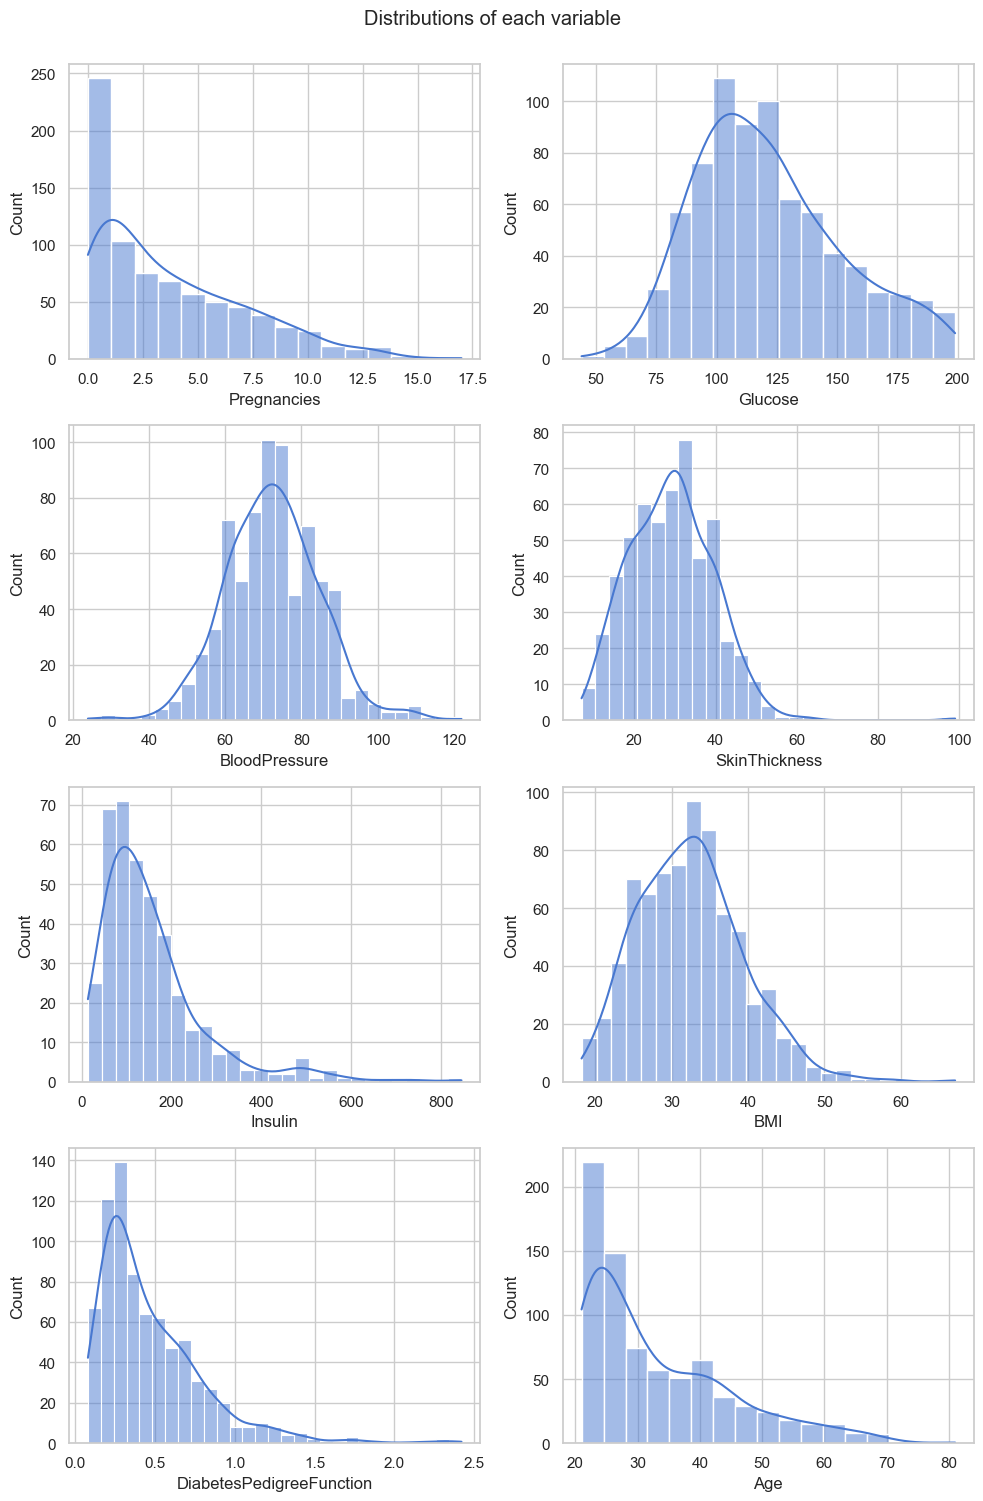

In [29]:

predictors = ["Pregnancies", "Glucose", "BloodPressure","SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(4,2, figsize = (10,15))
axes = axes.flatten()

for i, value in enumerate(predictors):
    sns.histplot(data = df, x = value, kde = True, ax = axes[i], bins = "fd")
    axes[i].set_xlabel(value)

plt.suptitle("Distributions of each variable", y = 1.0)
plt.tight_layout()


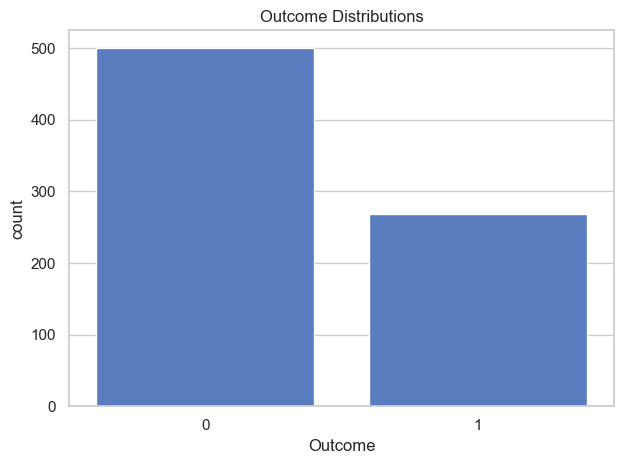

In [30]:
sns.countplot(x = df["Outcome"])
plt.title("Outcome Distributions")
plt.tight_layout()


### 6.3 Quantifying skewness

In [31]:
for value in predictors:
    print(value, ":", df[value].skew())


Pregnancies : 0.9016739791518588
Glucose : 0.5309885349396285
BloodPressure : 0.13415273171959252
SkinThickness : 0.690619013984192
Insulin : 2.166463843812443
BMI : 0.5939697505712673
DiabetesPedigreeFunction : 1.919911066307204
Age : 1.1295967011444805


The Outcome variable is binary, therefore, skewness is not viable and a class distribution is preferred

In [32]:
df.groupby("Outcome").size()

Outcome
0    500
1    268
dtype: int64

### Detailed Interpretation
#### Pregnancies
The pregnancies variable displays a strong right-skew supported by the mean (3.84) being greater than the median (3.0) and a skew of 0.9, suggesting a longer right tail likely influenced by the presence of high values. The standard deviation of 3.37 relative to the mean (3.84) is high and indicates that on average, the values deviate by 3.37 units from the mean. The dataset displays a range of values from 0 to 17 and when coupled with the standard deviation suggests a wide dispersion of values in the overall dataset. The central 50% ranges between the lower and upper quartiles 1 and 6 respectively, and when compared against the standard deviation, it suggests that the presence of extreme values likely influences the longer upper tail.


#### Glucose
The distribution appears moderately right-skewed, supported by a skewness value of 0.54 and a slight difference between the mean (121 mg/dL) and the median (117 mg/dL). This indicates a moderate concentration of observations on the lower end with a gradual tail extending towards higher values. The values display a large spread ranging from 44 to 199 mg/dL with the central 50% of the population concentrating between 99(Q1) and 141(Q3) mg/dL suggesting that most values cluster with the relatively smaller range and the presence of fewer high readings contributing to the longer right tail distribution. A standard deviation of 30 mg/dL from the mean (121.69 mg/dL), suggests a moderate variability around the mean.


#### Blood Pressure
The distribution appears roughly symmetric, supported by a skewness value of 0.13. Blood pressure values range from 24 to 122 mmHg, suggesting a wide overall spread, however, the interquartile range (64 to 80 mmHg) indicates that the middle 50% of observations are relatively tightly clustered, reflecting low variability in the central population. The slight positive skew suggests an extended right tail likely caused by a few higher blood pressure values on the upper tail. Some gaps between bars of the histogram are also observed on the upper and lower tail alongside a few extreme values, which may reflect possible binning effects, low-density regions or genuine statistical outliers. Further analysis will be needed to determine whether these values are as a result of rare extreme values or data quality issues.


#### Skin Thickness
The histogram distribution displays a moderate right-skew largely driven by high-end observations that elongate the right tail. A minimal difference is observed between the mean (29.15 mm) and median (29.0 mm) along with a skewness of 0.69, suggesting that the distribution is roughly symmetric with fewer upper range values pulling the positive end of the distribution and influencing the skew metric. The feature displays a wide range from 7 mm to 99 mm with a standard deviation of 10.5 mm from the mean (29.2 mm), indicating a wide spread of values in the dataset with moderate dispersion from the mean. The central population concentrates between 22 and 36 mm, suggesting a low central variability. The wide overall spread compared against the relatively smaller IQR range also suggests that the longer right tail is likely driven by the presence of extreme high values.
A visible gap is also observed on the upper end alongside a few extreme values and will be further evaluated during outlier analysis.
It is also important to note that skewness may be also be influenced by the substantial number of missing skin thickness values, affecting the accuracy of the distribution.


#### Insulin
The distribution exhibits a strong right skew, with the majority of participants clustering within the lower to mid-range of the distribution. This asymmetry is likely influenced by the presence of extremes that lengthen the distribution at the upper tail, and high number of missing values affecting accuracy of the distribution. The values display a wide spread with values ranging from 14 to 846 μU/mL, and a standard deviation of 118.78 μU/mL indicating a large dispersion from the mean (155.55 μU/mL). The interquartile range from 76.25 to 190 μU/mL indicates a low central variability relative to the overall spread. Visible gaps between bars of the histogram are also observed on the positive end, and will be further evaluated during outlier analysis. Insulin also exhibits a high number of missing values, which may influence the representative nature of the distribution.


#### BMI
The BMI shows a moderate right skew supported by a value of 0.59, and a difference between the mean(39.46 kg/m²) and median(32.3 kg/m²), suggests that the distribution is approximately symmetric, and the distortion is likely influenced by extreme values and gaps between bars observed on the upper tails of the histogram. The values exhibit a moderate spread ranging from 18.2 to 67.1 kg/m² with a standard deviation of 6.9, showing lower variability of values from the mean (32.5 kg/m²). The central population displays a tight clustering of observations between 32 and 36 kg/m², suggesting a low central variability, such that slight deviations from this range affect skew values, mean, and standard deviations. Comparing the overall and interquartile ranges, the distribution suggests that the skew is largely driven by few upper end values.
Outliers are also identified on the upper tail, indicating the presence of high values separated from the population.


#### Diabetes Pedigree Function
This variable is strongly right-skewed, with a skew value of 1.92 and more observations clustered on the lower end of the distribution with a longer right tail driven by extremes. The values range from 0.08 mg/dL to 2.42 mg/dL with a standard deviation of 0.33 mg/dL from the mean (0.47), indicating a wide population spread with a large dispersion of values from the mean. The overall range, compared with a relatively narrow IQR range between 0.24 and 0.62, suggests low central variability, with the long right tail driven by extremes.


#### Age
The distribution shows a strong right skew, with values clustering on the lower end and gradually decreasing towards the upper end, indicating that most patients are younger in age with fewer older participants. Specifically, a 75th percentile of 41 shows that most individuals (75% of the population) are below the age of 41 with the remaining 25% showing age ranges up to 81. The values range widely from 21 to 81 years and display a moderate dispersion from the mean (33.24), supported by a standard deviation of 11.76. The IQR ranges from 24 to 41 years and suggests a moderate central variability.


#### Outcome
The outcome is a binary variable and is therefore not normally distributed. The mean indicates class imbalance, with approximately 35% (268 observations) of individuals belonging to the positive class(outcome = 1). The standard deviation reflects a binary dispersion rather than continuous variability and is not interpreted in the same way as continuous features, its value of 0.47 indicates a near balanced dataset such that each outcome is substantially represented in the dataset.


### Key Summary
Overall, most variables exhibit moderate to strong right skew for all variables, largely driven by extremes and potential outliers with Insulin, Diabetes Pedigree Function and Age displaying the greatest asymmetry, except Blood pressure, which indicated a roughly normal distribution. The IQR for several variables also differ from overall range, suggesting the presence of extreme observations that may require further outlier analysis and preprocessing.


### 6.4 Determining Outliers

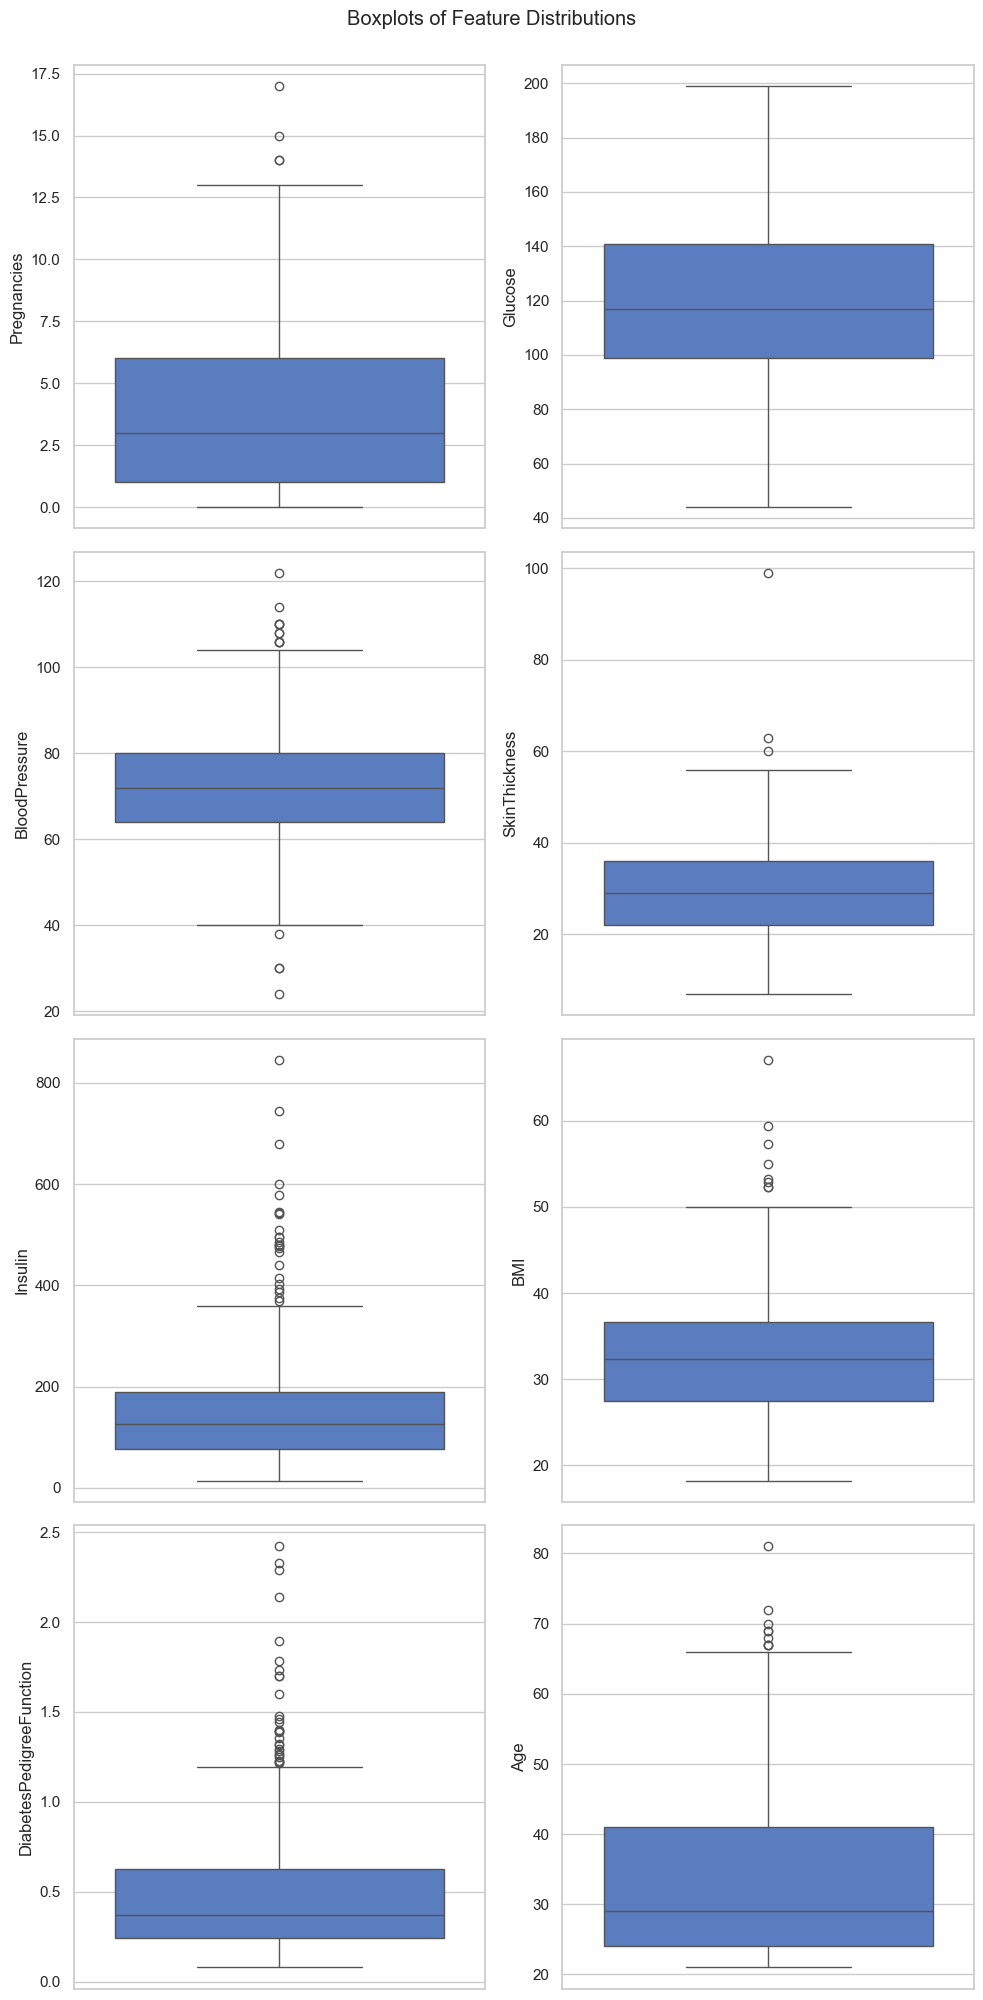

In [33]:
def plot_boxplot(n_rows, n_columns, data, predictors, title = "Boxplots of Feature Distributions", x = None, figsize = (10,20)): 
    fig, axes = plt.subplots(n_rows, n_columns, figsize = figsize)
    axes = axes.flatten()
    for i, variable in enumerate(predictors):
        sns.boxplot(data = data, x = x, y = variable, ax=axes[i])
    fig.suptitle(title, y = 1.0)
    plt.tight_layout()
    plt.show()


plot_boxplot(4, 2, df, predictors, figsize = (10,20))

### 6.5 Determining Interquartile range and outliers - Statistical Abnormality

In [34]:
range_summary = []  

for value in predictors:

    Q1 = df[value].quantile(0.25)
    Q3 = df[value].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[value] < lower) | (df[value] > upper)]

    low_outliers = (df[value]< lower).sum()
    high_outliers = (df[value]> upper).sum()

    range_summary.append({
                        "Feature": value,
                        "Q1": Q1,
                        "Q3": Q3,
                        "IQR": IQR,
                        "Low_Outlier_Threshold": lower,
                        "High_Outlier_Threshold": upper,
                        "Low_Outliers": low_outliers,
                        "High_Outliers": high_outliers})
    
range_summary = pd.DataFrame(range_summary)

range_summary




,Feature,Q1,Q3,IQR,Low_Outlier_Threshold,High_Outlier_Threshold,Low_Outliers,High_Outliers
0,Pregnancies,1.00000,6.00000,5.0000,-6.500,13.500,0,4
1,Glucose,99.00000,141.00000,42.0000,36.000,204.000,0,0
2,BloodPressure,64.00000,80.00000,16.0000,40.000,104.000,4,10
3,SkinThickness,22.00000,36.00000,14.0000,1.000,57.000,0,3
4,Insulin,76.25000,190.00000,113.7500,-94.375,360.625,0,24
5,BMI,27.50000,36.60000,9.1000,13.850,50.250,0,8
6,DiabetesPedigreeFunction,0.24375,0.62625,0.3825,-0.330,1.200,0,29
7,Age,24.00000,41.00000,17.0000,-1.500,66.500,0,9


### 6.6 Classifying Clinical Thresholds

In [35]:

hypoglycemic = (df["Glucose"] < 70).sum()
high_glucose = ((df["Glucose"] >= 140) & (df["Glucose"] <200)).sum()
hyperglycemic = (df["Glucose"] >= 200).sum()

hypotensive = (df["BloodPressure"] < 60).sum()
elevated_bp = ((df["BloodPressure"] > 80) & (df["BloodPressure"] < 90)).sum()
hypertensive = (df["BloodPressure"] >= 90).sum()

underweight = (df["BMI"] < 18.5).sum()
overweight = ((df["BMI"] >= 25) & (df["BMI"] < 30)).sum()
obese = (df["BMI"] >= 30).sum()

low_risk_dpf = (df["DiabetesPedigreeFunction"] < 0.5).sum()
high_risk_dpf = (df["DiabetesPedigreeFunction"] > 1).sum()

number_of_outliers = [[hypoglycemic, high_glucose, hyperglycemic, hypotensive, elevated_bp, hypertensive, underweight, overweight, obese, low_risk_dpf, high_risk_dpf]]

pd.DataFrame(number_of_outliers, columns = ["hypoglycemic", "high_glucose", "hyperglycemic", "hypotensive", "elevated_bp", "hypertensive", "underweight", "overweight", "obese", "low_risk_dpf", "high_risk_dpf"])

,hypoglycemic,high_glucose,hyperglycemic,hypotensive,elevated_bp,hypertensive,underweight,overweight,obese,low_risk_dpf,high_risk_dpf
0,11,197,0,86,105,60,4,179,472,491,51


### Clinical Vs Statistical Abnormality

The statistical boundaries and clinical thresholds do not coincide with each other, but are not expected to, given the clinical thresholds exist independently of the dataset, while the statistical ranges are dependent on the distribution of the observed data.  
The statistical ranges help to identify observations that show abnormal values relative to the dataset, even in a clinically abnormal or high-risk population.  
Some values may be considered outliers statistically, but may still be clinically plausible and transforming or removing them from the dataset could likely eradicate a rare subset of the population.

### Detailed Interpretation
#### Glucose
No outliers were found to exceed the high or low statistical thresholds, indicating that there are no extreme deviations relative to the dataset, however, with a minimum value of 44 mg/dL, 11 observations were found below the clinical OGTT hypoglycemic threshold (< 70 mg/dL), with about 197 participants (25% of the population, given a 75th percentile of 141) within clinically elevated OGTT ranges (140 to 199 mg/dL) but none within the hyperglycemic range (> 200 mg/dL). Glucose levels as low as 44 are clinically possible but extreme and rare as they suggest severe hypoglycemic states, hence should be treated as atypical during further analysis and modelling
It is also interesting to note that there are many observations with an outcome of one, yet none of the observation have glucose levels above 200, implying that diabetes association in this dataset might not be solely off clinical Glucose OGTT ranges.


#### Blood Pressure
An IQR of 16.0 mmHg confirms a low variability in the distribution, hence, the outlier thresholds are likely sensitive to slight deviations in values from the central population, however, identified outliers would have to be assessed for clinical plausibility as they could represent a rare but still clinically meaningful population.
86 participants are found to be below clinical threshold with blood pressure values below 60 mm Hg, out of which 4 were considered statistically abnormal for the distribution with blood pressures above the minimum blood pressure of 24 mmHg and below the lower statistical outlier threshold of 40 mmHg. While there is no widely accepted cut-off, a diastolic blood pressure below 40 mmHg is critically low and contextually suspicious, particularly for a non-ICU dataset, however, it is still not impossible and should have to be handled carefully during modelling.
105 participants were found to have elevated blood pressures between 80 and 89 mmHg, and 60 participants with hypertensive levels above 90 mmHg, out of which 10 were flagged as statistically abnormal relative to the dataset with blood pressures above the high outlier threshold (104 mmHg) and below the maximum value of 122 mmHg. Values as high as 122 mmHg are also physiologically possible, but very rare as they suggest a severe hypertensive state, hence should be treated as potential outliers during further analysis and modelling.


#### Skin Thickness
Interpretation is based off of Statistical observations only for the aforementioned reasons.
With a minimum value of 7 mm, no observations were found below the lower outlier threshold (1.0). However, 3 observations displayed statistically abnormal values above the high outlier threshold of 57 mm and below the maximum of 99 mm. Such high extremes are rare but still physiologically possible, hence should be imputed with care and treated as a rare subgroup rather than atypical.  
With only 3 values dispersed between such a wide range, this likely explains the significant gap and isolated bar observed in the histogram distribution. Further analysis would be needed to assess whether the extremes represent a rare but clinically meaningful group or potential data errors.
It is also likely that the distribution is influenced by the high number of missing observations in this dataset.


#### Insulin
Interpretation is based off of Statistical observations only for the aforementioned reasons.
With a minimum value of 14 μU/mL, no low statistical outliers were observed, however 24 observations were identified as upper statistical outliers with values ranging from 360.63 to 846 μU/mL. These values are still clinically plausible, and should be handled cautiously during modelling as they likely represent a rare subset of the population. It is also likely that these values represent the sparsely dispersed bars on the histogram, and the gaps suggest binning artifacts or high number of missing observations in the dataset.


#### BMI
The dataset displayed a minimum BMI value of 18.2 kg/m², hence, no observations were detected below the lower statistical threshold of 13.85, however 4 observations were found below the clinical threshold of 18.5 kg/m²(underweight) but above the minimum value (18.2 kg/m²). A large difference is not seen between the minimum and the clinical threshold, suggesting that those values are plausible, and the participants are not severely underweight, hence no suspicion is raised since they are just below the threshold for underweight and are still clinically possible
The higher clinical threshold was between 25 kg/m² and 29.9 kg/m² for overweight classification and above 30 for obese, out of which 179 were flagged as overweight and 492 as obese. From the clinically obese subgroup, 8 were flagged as statistical outliers above the high outlier threshold of 50.25 kg/m² and below the maximum value of 67 kg/m². Such high values are still biologically possible.
It is also important to note that there is a likely increased sensitivity of the upper outlier threshold to slight variations, due to the rough symmetry of the distribution and lower-end leaning and tightly clustered central population (27 to 36 kg/m²) compared to the overall spread of the data (18.2 to 67.1 kg/m²).
Also, taking into account the statistical values, about 87% of the population is either overweight (23%) or obese(64%), and with about 0.5% being underweight, leaving about 12.5% within the normal ranges. 



Outliers for variables, like Diabetes Pedigree Function cannot really be biologically interpreted for viability against clinical ranges as they are dataset dependent and are not direct physical measurements for the human body like glucose, Insulin, etc. They do not have any clinically "normal" range. Hence, we cannot determine if they are plausible biologically. 
Distribution would be used to determine any statistical extremes relative to the dataset.
It is also important to note that variables like Age can have real world constraints, for example, age has a biological ceiling of about 120 years.


#### Diabetes Pedigree Function
75% of the population have their DPF between 0.078 (minimum value) and 0.62 (Q3), with the remaining 25% ranging up to a value of 2.42(maximum)
491 observations displayed DPF values below 0.5 with 51 displaying DPF values above 1.0, confirming the right skew histogram distribution noted earlier as well as the shift of the IQR range (0.2 to 0.6) towards the lower end of the overall spread (0.07 to 2.42).
No low statistical outliers were identified, however, out of the 51 participants with DPF greater than 1.0, 29 were flagged as high statistical outliers above a threshold of 1.2, with values. As DPFs represent statistical values that indicate a genetic score for family history of diabetes, values as low or high as 0.07 and 2.42 are plausible

#### Age
No low statistical outliers (below the low outlier threshold of -1.5) were observed however 9 participants were found to show abnormally high ages (above outlier threshold of 66.5) relative to dataset. However, with a maximum of 81, the age ranges observed are plausible, and removing these outliers could significantly affect accuracy during modelling.

#### Pregnancies
75% of the population display between 0 and 6 pregnancies. No low statistical outliers were observed given the lowest value is 0, however, 4 high outliers were found to have more than 13 pregnancies ranging to a maximum of 17 pregnancies. Though rare, such high number of pregnancies is still physiologically possible and hence should not be imputed or dropped from the dataset.


### Key Summary
With most variables in the dataset exhibiting moderate to strong right skew driven by upper-tail observations, statistical outliers are frequent but largely remain clinically plausible, indicating that extreme values reflect real physiological variation rather than data errors.
Overall, the data consists of heterogeneous populations with statistically rare but clinically meaningful high-value extremes, particularly in physiological variables like BMI, Blood Pressure, Skin Thickness and Insulin. This makes strict outlier removal inappropriate with adequate clinical context. Owing to this, careful handling of skew and extreme observations is required as they could carry predictive signal.


### 6.7 Differences in Distributions between the subgroups
#### 6.7.1 Assessing Missing Patterns
 
Investigating for changes in variable distributions within the different subgroups, i.e.,
- Observations with missing insulin values, but not Skin thickness values,
- Observations with both missing insulin and skin thickness values
- Observations with neither Skin thickness nor insulin values missing

The other missing values for variables like Glucose, Blood pressure, and BMI, will not be used as part of the criterion to assess missingness as these values are too small to indicate any comparative differences.

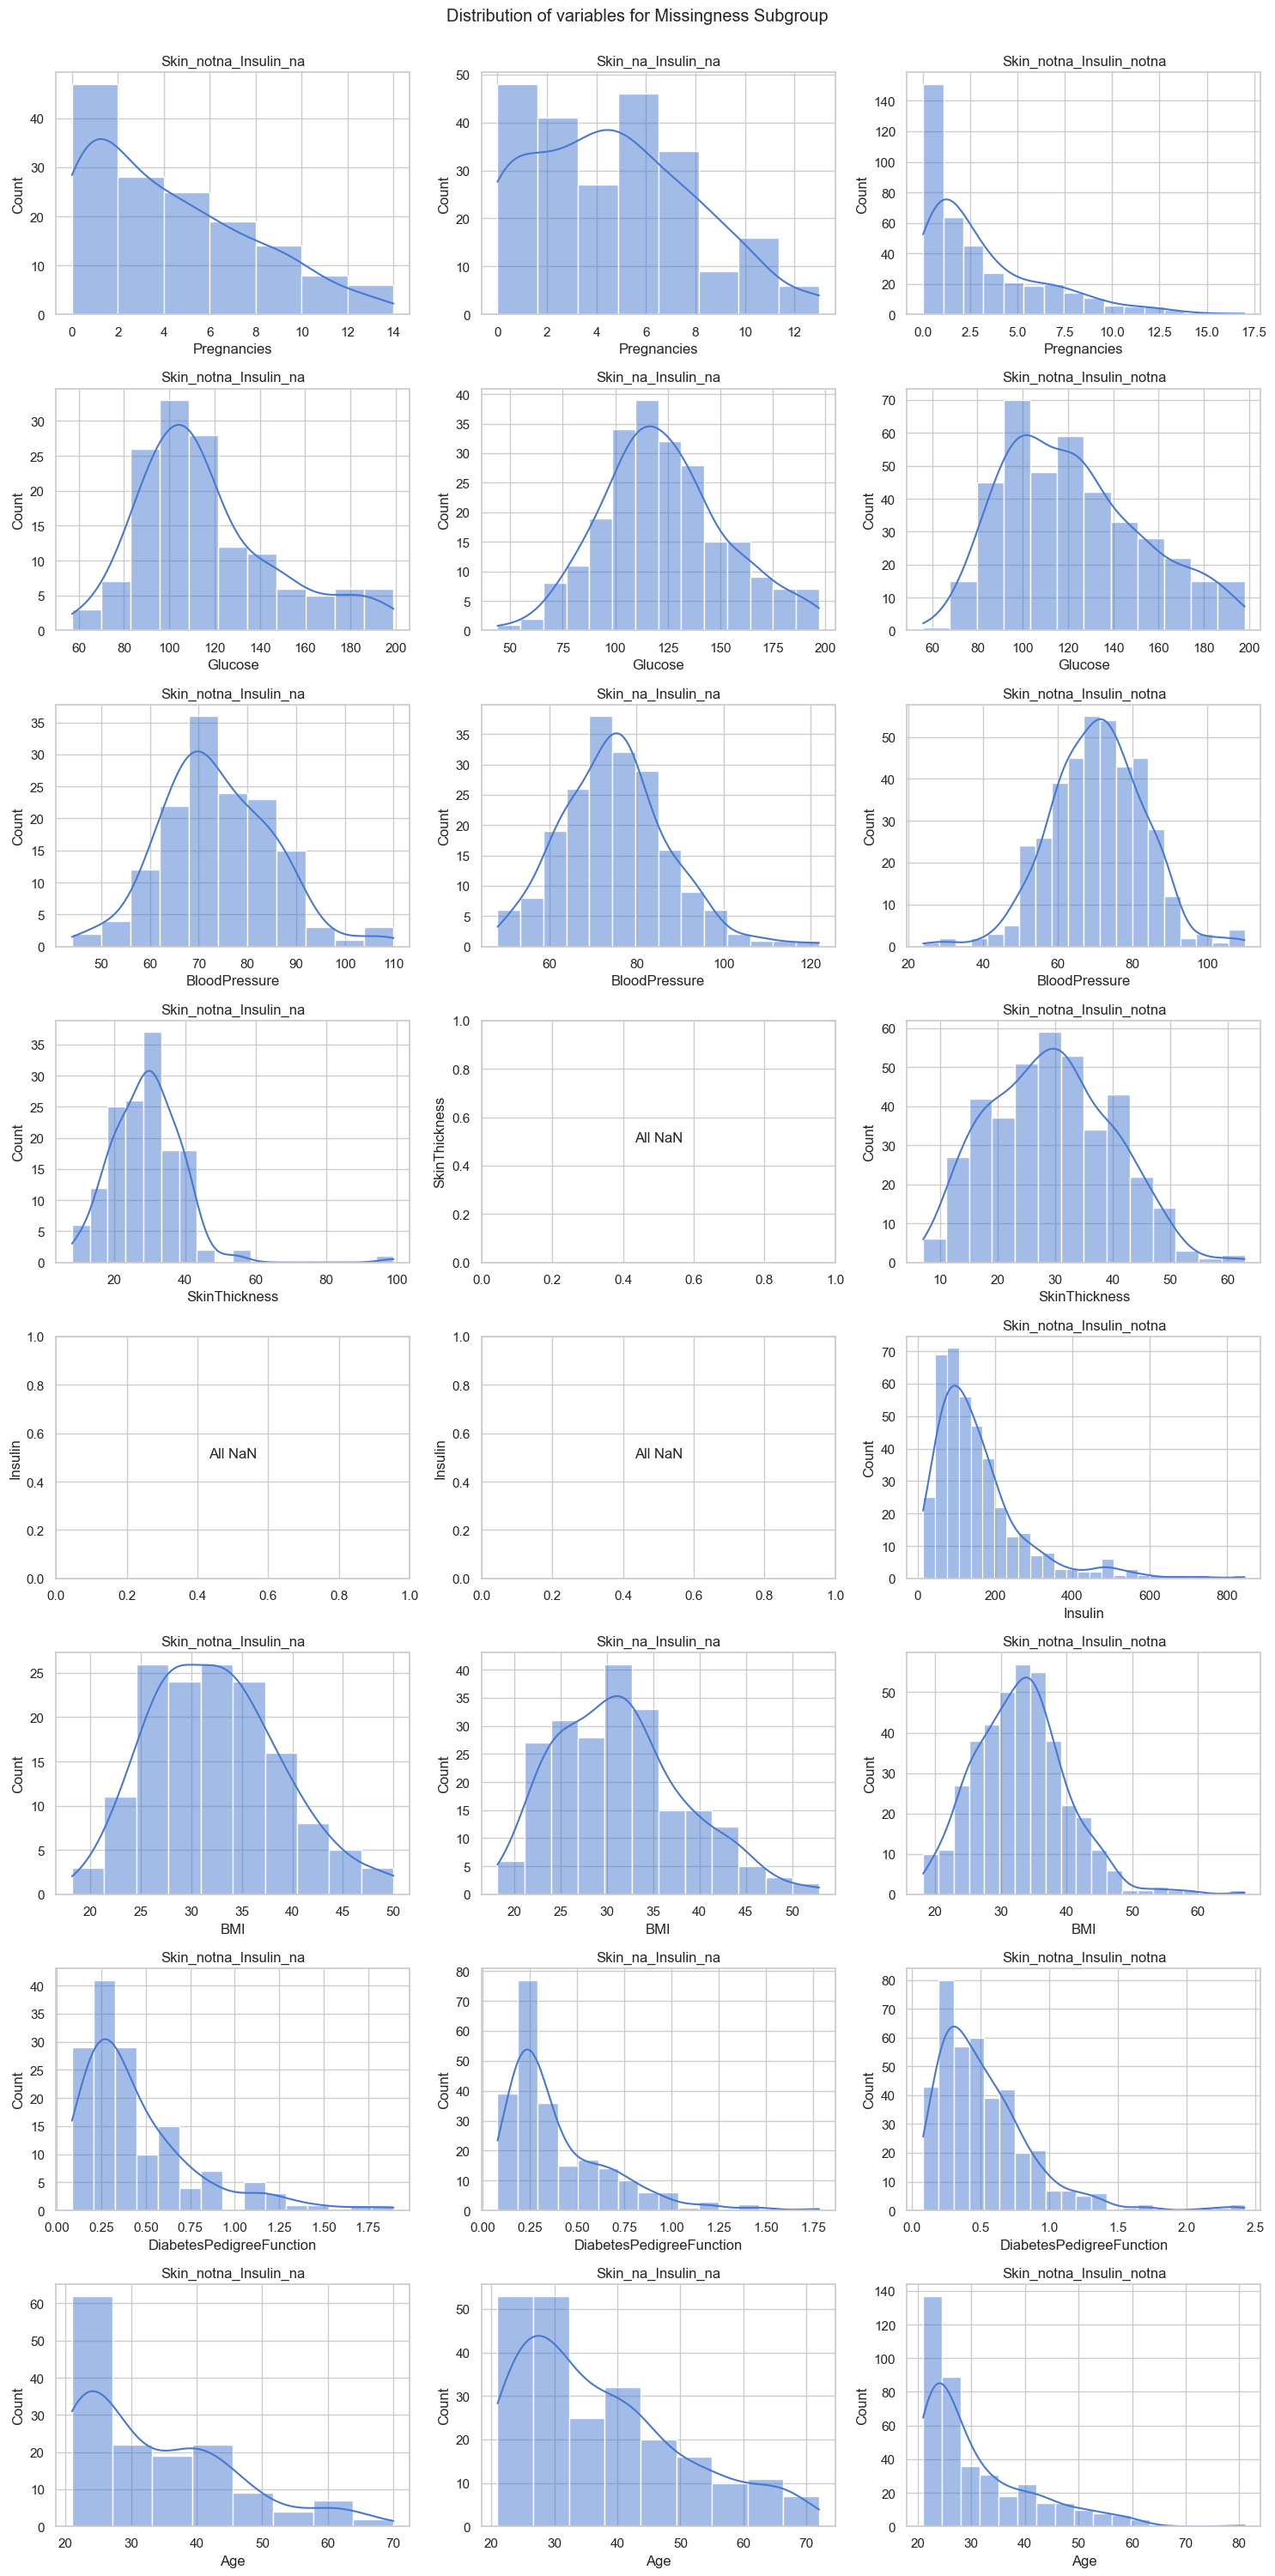

In [36]:
predictors = ["Pregnancies", "Glucose", "BloodPressure","SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(8,3, figsize = (15,30))

skin_notna_insulin_na = df[(df["SkinThickness"].notna()) & (df["Insulin"].isna())] #147 patients
skin_na_insulin_na = df[(df["SkinThickness"].isna()) & (df["Insulin"].isna())] #227 patients
skin_notna_insulin_notna = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())] #394 patients



for i, variable in enumerate(predictors):
    
    if skin_notna_insulin_na[variable].notna().sum() > 0 :
        sns.histplot(data = skin_notna_insulin_na[variable], ax = axes[i,0], kde = True, bins = "fd")
        axes[i, 0].set_title("Skin_notna_Insulin_na")
        
    else:
        axes[i,0].text(0.5,0.5, "All NaN", ha = "center", transform = axes[i,0].transAxes) # all Insulin values are missing in this subgroup
        axes[i, 0].set_ylabel(variable)

    if skin_na_insulin_na[variable].notna().sum() > 0:
    
        sns.histplot(data = skin_na_insulin_na[variable], ax = axes[i,1], kde = True, bins = "fd")
        axes[i, 1].set_title("Skin_na_Insulin_na")
    else:
        axes[i,1].text(0.5, 0.5, "All NaN", ha = "center", transform = axes[i,1].transAxes)  # all Insulin and Skin Thickness values are missing in this subgroup
        axes[i, 1].set_ylabel(variable)

    if  skin_notna_insulin_notna[variable].notna().sum() > 0:
        sns.histplot(data = skin_notna_insulin_notna[variable], ax = axes[i,2], kde = True, bins = "fd")
        axes[i, 2].set_title("Skin_notna_Insulin_notna")
    else:
        axes[i,2].text(0.5, 0.5, "All NaN", ha = "center", transform = axes[i,2].transAxes)
        axes[i, 2].set_ylabel(variable)
fig.suptitle("Distribution of variables for Missingness Subgroup", y = 1.0)
plt.tight_layout()

#keeping in mind that: skin_notna_insulin_na = 147 observations, skin_na_insulin_na = 227 observations, skin_notna_insulin_notna = 394

#### 6.7.2 Quantifying Skew for Missingness Subgroups

In [37]:
predictors = ["Pregnancies", "Glucose", "BloodPressure","SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

# The whole dataset = df
# individuals with missing insulin values, but not missing skin thickness values
skin_notna_insulin_na = df[(df["SkinThickness"].notna()) & (df["Insulin"].isna())] #147 patients
# patients with missing skin thickness AND insulin values
skin_na_insulin_na = df[(df["SkinThickness"].isna()) & (df["Insulin"].isna())] #227 patients
# patients with both skin thickness and Insulin values present
skin_notna_insulin_notna = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())] #394 patients

list_skin_notna_insulin_na = []
list_skin_na_insulin_na = []
list_skin_notna_insulin_notna = []

for variable in predictors:
    if skin_notna_insulin_na[variable].notna().sum() > 0:
        list_skin_notna_insulin_na.append(skin_notna_insulin_na[variable].skew())

    else:
        list_skin_notna_insulin_na.append(np.nan)

    if skin_na_insulin_na[variable].notna().sum() > 0:
        list_skin_na_insulin_na.append(skin_na_insulin_na[variable].skew())
    
    else:
        list_skin_na_insulin_na.append(np.nan)

    if  skin_notna_insulin_notna[variable].notna().sum() > 0:
        list_skin_notna_insulin_notna.append(skin_notna_insulin_notna[variable].skew())
    else:
        list_skin_notna_insulin_notna.append(np.nan)

subgroup_skew = pd.DataFrame({"Skin_notna_Insulin_na": list_skin_notna_insulin_na,
                              "Skin_na_Insulin_na": list_skin_na_insulin_na,
                              "Skin_notna_Insulin_notna": list_skin_notna_insulin_notna}, index = predictors)
subgroup_skew

,Skin_notna_Insulin_na,Skin_na_Insulin_na,Skin_notna_Insulin_notna
Pregnancies,0.745345,0.406235,1.340621
Glucose,0.914843,0.327576,0.519604
BloodPressure,0.364352,0.532711,-0.085918
SkinThickness,2.006564,NaN,0.217904
Insulin,NaN,NaN,2.166464
BMI,0.442506,0.565410,0.667561
DiabetesPedigreeFunction,1.812098,1.792679,1.955479
Age,0.950336,0.794783,1.407345


In [38]:
skin_notna_insulin_na.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,147.000000,143.000000,145.000000,147.000000,0.0,146.000000,147.000000,147.000000,147.000000
mean,4.115646,116.335664,73.655172,29.278912,NaN,32.419863,0.449388,33.551020,0.340136
std,3.556813,30.869317,11.524960,10.438195,NaN,6.443726,0.331943,11.892892,0.475374
min,0.000000,57.000000,44.000000,8.000000,NaN,18.200000,0.085000,21.000000,0.000000
25%,1.000000,95.500000,66.000000,22.000000,NaN,27.600000,0.236000,23.500000,0.000000
50%,3.000000,109.000000,72.000000,30.000000,NaN,32.200000,0.346000,30.000000,0.000000
75%,6.500000,130.000000,82.000000,35.500000,NaN,35.975000,0.570500,41.000000,1.000000
max,14.000000,199.000000,110.000000,99.000000,NaN,50.000000,1.893000,70.000000,1.000000


In [39]:
skin_na_insulin_na.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,227.000000,227.000000,194.000000,0.0,0.0,218.000000,227.000000,227.000000,227.000000
mean,4.638767,123.449339,75.025773,NaN,NaN,31.373853,0.393291,37.251101,0.387665
std,3.350062,29.572931,12.305454,NaN,NaN,6.952505,0.276871,13.062933,0.488294
min,0.000000,44.000000,48.000000,NaN,NaN,18.200000,0.078000,21.000000,0.000000
25%,2.000000,105.000000,66.000000,NaN,NaN,25.925000,0.203000,27.000000,0.000000
50%,4.000000,120.000000,74.500000,NaN,NaN,30.850000,0.282000,34.000000,0.000000
75%,7.000000,140.500000,82.000000,NaN,NaN,35.300000,0.536500,45.000000,1.000000
max,13.000000,197.000000,122.000000,NaN,NaN,52.900000,1.781000,72.000000,1.000000


In [40]:
skin_notna_insulin_notna.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,394.000000,393.000000,394.000000,394.000000,394.000000,393.000000,394.000000,394.000000,394.000000
mean,3.286802,122.615776,70.654822,29.106599,155.548223,33.072519,0.525543,30.814721,0.329949
std,3.209635,30.822276,12.469919,10.504273,118.775855,7.023947,0.350127,10.198971,0.470792
min,0.000000,56.000000,24.000000,7.000000,14.000000,18.200000,0.085000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,21.000000,76.250000,28.400000,0.270250,23.000000,0.000000
50%,2.000000,119.000000,70.000000,29.000000,125.000000,33.200000,0.449500,27.000000,0.000000
75%,5.000000,143.000000,78.000000,36.750000,190.000000,37.100000,0.687000,36.000000,1.000000
max,17.000000,198.000000,110.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Detailed Interpretation
#### Pregnancies
As stated earlier, 4 high outliers were observed (relative to the dataset) with more than 13 pregnancies. These values are distributed between the skin_notna_insulin_na subgroup and the skin_notna_insulin_notna subgroup, leaving the skin_na_insulin_na subgroup with a maximum of 12 pregnancies.
The skin_notna_insulin_na and skin_notna_insulin_notna subgroups display strong right skews with values that gradually decrease towards the upper end of the tail, however, the skin_na_insulin_na subgroup did not display a smooth decline towards the upper tail. After an initial decline, the distribution rose again to create a smaller secondary peak before gradually tapering off. This suggests a possible relation between the absence of both skin thickness and insulin values and the pregnancies variable. Further investigation is needed to determine whether the bimodal-like peak is really true or a binning artifact.  

#### Glucose 
All three subgroups seem to have similar glucose distributions, spreads of 40 or 60 to 200, and similar central peaks around 100 to 120.  
The distribution for skin_na_insulin_na appears to have the lowest right skew (supported by a skew of 0.33) with asymmetry increasing in the skin-notna_insulin_notna(0.52) subgroup and finally to the skin_notna_insulin_na subgroup displaying the largest right skew(0.91) among the three subgroups. The glucose distributions seem consistent across all three subgroups suggesting missingness is unlikely to be strongly associated with underlying glucose levels. Given that sample size increases from skin_notna_insulin_na(147) to Skin_na_insulin_na(227) and finally to skin_notna_insulin_na(394), the skew of the skin_notna_insulin_na subgroup is likley amplified by its sample size and fewer observations in the upper tail.
The 4 missing values for glucose are found within the skin_notna_insulin_na subgroup, with the remaining 1 in the skin_notna_insulin_notna subgroup, coinciding with earlier missingness analysis.

#### Blood Pressure
No meaningful difference in mean or standard deviation is observed between the three subgroups.
While the skin_na_insulin_na and skin_notna_insulin_na subgroups display similar spreads (44 and 122) and IQR ranges (between 66 and 82), the skin_notna_insulin_notna subgroup displayed lower negative end with an overall spread of 24 to 110, and an IQR range of (62 to 78) that shares a similar length with the two other subgroups, but is slightly shifted towards the lower end of the distribution. The skin_notna_insulin_na and skin_na_insulin_na subgroups also display similar right skews with slight differences in skew values (0.36 and 0.53 respectively), while the skin_notna_insulin_notna subgroup displayed a weak left skew (-o.09). Overall, there is no strong evidence to show that there is prominent change in blood pressure distributions among the three subgroups.
Two (2) missing values were found within the skin_notna_insulin_na subgroup with 33 missing values within the skin_na_insulin_na subgroup coinciding with earlier missingness pattern analysis.

#### Skin Thickness
Values for skin thickness are absent in the skin_na_insulin_na subgroup, hence comparisons can only be made between the skin_notna_insulin_na and skin_notna_insulin_notna subgroup.  
The skin_notna_insulin_na subgroup showed a relatively stronger right skew to the skin_notna_insulin_notna subgroup supported by skewness values of 2.0 and 0.21 respectively. However, the strong skew in the skin_notna_insulin_subgroup is likely significantly distorted by the presence of small number of extremes observed in the histogram, lying between from 90 and 100. This is confirmed by the presence of outliers identified earlier, the comparatively wider overall range but similar IQR range as well as the higher maximum value (99) of this subgroup. This also suggests an enhanced sensitivity of the skew in a relatively smaller population size. Further analysis would be needed to prove this distortion. 
It is important to note that this does not mean that those values are insignificant, though rare, they are still physiologically possible and should not be dismissed, despite their significant effect on the skew. These observations would still be retained during modeling, but their effects would need to be managed, as they have potential to create bias.  

#### Insulin
Comparison cannot be made using insulin values, as they are missing in two subgroups.

#### BMI 
All three subgroups display a moderate right skew with the skin_notna_insulin_notna subgroup exhibiting the largest right skew (0.66), followed by skin_na_insulin_na (0.57), and finally, skin_notna_insulin_na(0.44), with the skewness of the former subgroup likely enhanced by the presences of outliers identified during earlier outlier analysis, and confirmed by a relatively wider range, larger maximum value and extreme values on the upper end of the histogram that elongate the tail.
A possible plateau or multimodal distribution is seen in the insulin only subgroup, however, this seems to gradually diminish into a sharp peak with increasing sample size from the skin_na_insulin_na subgroup to the skin_notna_insulin_notna subgroup, but further analysis would be needed to support this, as the observed flat-line may be influenced by smaller participation size or binning artifacts.
Overall, there is no strong evidence to show that there is prominent change in BMI distributions among the three subgroups.  
Nine (9) out of the 11 missing values for BMI were found within the skin_na_insulin_na subgroup with one missing value, each found in the two remaining subgroups.


#### Diabetes Pedigree Function
No significant difference is observed among the three subgroups, as they all indicate strong right skewness ranging from 1.78 to 1.89, with strong similarities in peaks between 0.0 to 0.25. No significant difference in distribution variability is observed as values for both skin_notna_insulin_na subgroup and skin_na_insulin_na subgroup had distributions ranging from 0.08 to 1.89, with the skin_notna_insulin_notna subgroup displaying a slightly wider range ending at 2.4, likely influencing it srelatively largest skew size, however, this is not meaningful enough to incur any meaningful difference and is likely to be influenced by extreme values and differences in group sizes.


#### Age
No significant difference is observed among the three subgroups as distributions differ slightly, with no significant differences in right skewness ranging from 0.79 (skin_na_insulin_na) to 1.4. Modal values are also clustered from age 21 to 25 across all three subgroups.

### 6.8 Investigating Observed Patterns
#### 6.8.1 Assessing Bimodal-like Peak in Pregnancies variable for skin_na_insulin_na Subgroup.

In [41]:
skin_na_insulin_na["Pregnancies"].value_counts().sort_index()

Pregnancies
0     32
1     16
2     23
3     18
4     27
5     25
6     21
7     16
8     18
9      9
10    12
11     4
12     1
13     5
Name: count, dtype: int64

This indicates that the highest point in the data is 0, with an unstable reduction in number of pregnancies followed by a secondary bump at 4 and 5, hence it cannot be referred to as bimodal. Overall, the distribution of pregnancies for the subgroup is unimodal, with an inconsistent decline as the number of pregnancies increases.

#### 6.8.2 Assessing relationship between Skewness values and observed outliers for Skin Thickness variable in skin_notna_insulin_na subgroup

In [42]:
remove1 = skin_notna_insulin_na["SkinThickness"]
remove1 = remove1[remove1 < 90]
remove1.skew()



np.float64(0.05838182726647347)

The value of the skew significantly dropped from 2 to 0.06, indicating that the skewness value was heavily influenced by outliers in the distribution.

#### 6.8.3 Assessing relationship between Skewness values and observed outliers for BMI variable in skin_notna_insulin_notna subgroup

In [43]:
remove2 = skin_notna_insulin_notna["BMI"].dropna()
remove2 = remove2[remove2 < 60]
remove2.skew()

np.float64(0.45049214139676086)

The value of the skew dropped from 0.67 to 0.45, indicating that the skewness value was influenced by outliers in the distribution.

#### 6.8.4 Assessing Bimodal-like Peak in BMI variable for skin_notna_insulin_na Subgroup.

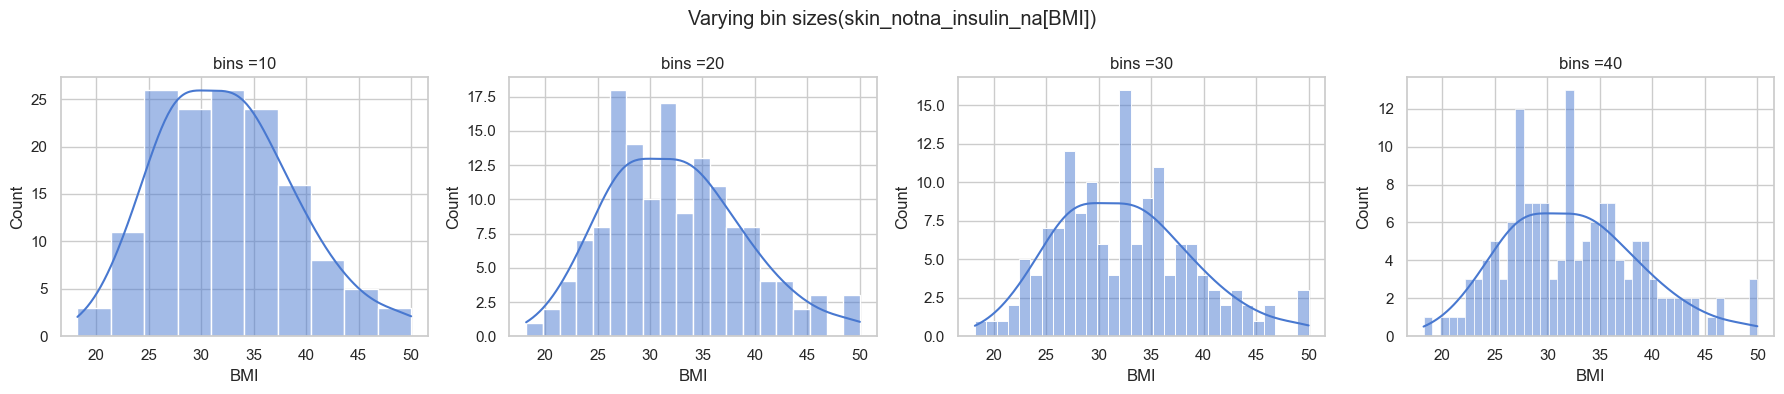

In [44]:

bin_size = [10, 20, 30, 40]

fig, axes = plt.subplots(1, 4, figsize = (18,4))

for i, value in enumerate(bin_size):
    sns.histplot(data = skin_notna_insulin_na["BMI"], ax = axes[i], bins = value, kde = True)
    axes[i].set_title("bins ="+ str(value))
fig.suptitle("Varying bin sizes(skin_notna_insulin_na[BMI])")
plt.tight_layout()

The plateau gradually diminishes with increasing size with more noticeable peaks, indicating that the plateau tendencies were influenced by binning artefacts.

#### Key Summary
Throughout the missingness-defined subgroups, the distributions of the variables showed similar central tendencies and dispersion with minor differences in skewness and tail behaviours, likely influenced by the presence of extreme values, outliers and subgroup size variations. Overall, the subgroups appear to represent the same underlying population, as no meaningful differences in structural distribution or subgroup effects were observed among the major missingness subgroups. 
Any observed differences between the subgroups are mainly influenced by sample size imbalance and the sensitivity of skewness to smaller subgroups rather than meaningful physiological changes in population structure. 
Overall, this suggests that missingness might not be a strong source of signal as it reflects data collection structure rather than biological distinctions.  
There are no potential signals observed to drive further analysis of individual variables within the subgroups, however, further investigation would still be done to determine if missingness is associated with outcome.

## 7.0 Bivariate and Correlation Analysis


In [45]:
# The whole dataset = df
# individuals with missing insulin values, but not missing skin thickness values
skin_notna_insulin_na = df[(df["SkinThickness"].notna()) & (df["Insulin"].isna())] #147 patients
# patients with missing skin thickness AND insulin values
skin_na_insulin_na = df[(df["SkinThickness"].isna()) & (df["Insulin"].isna())] #227 patients
# patients with both skin thickness and Insulin values present
skin_notna_insulin_notna = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())] #394 patients

### 7.1 Boxplot for Feature vs Outcome for each individual variable

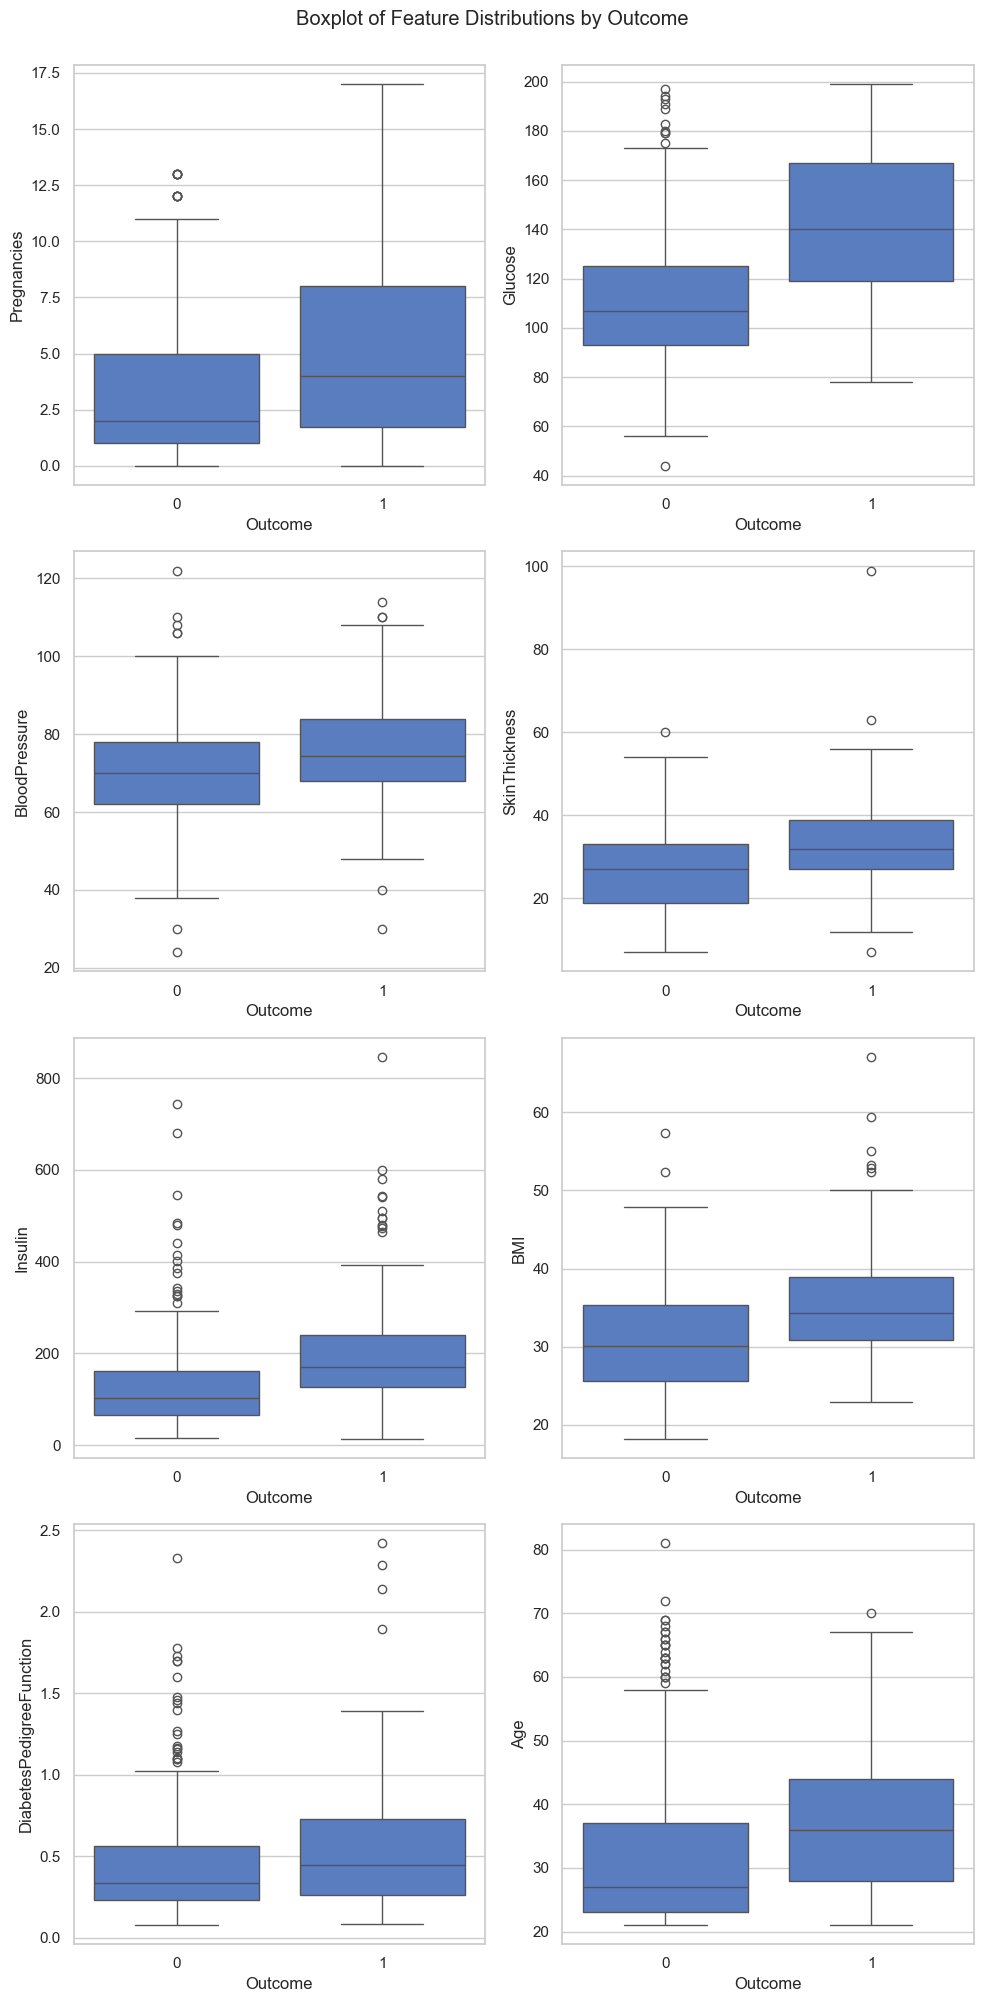

In [46]:
plot_boxplot(4, 2, df, predictors, title = "Boxplot of Feature Distributions by Outcome", x = "Outcome", figsize = (10,20))

In [47]:
table = {}
for value in df:
    if value != "Outcome":
        table[value] = df.groupby("Outcome")[value].describe()
table = pd.concat(table)
table


count        mean         std     min  \
                         Outcome                                          
Pregnancies              0        500.0    3.298000    3.017185   0.000   
                         1        268.0    4.865672    3.741239   0.000   
Glucose                  0        497.0  110.643863   24.776906  44.000   
                         1        266.0  142.319549   29.599199  78.000   
BloodPressure            0        481.0   70.877339   12.161223  24.000   
                         1        252.0   75.321429   12.299866  30.000   
SkinThickness            0        361.0   27.235457   10.026491   7.000   
                         1        180.0   33.000000   10.327595   7.000   
Insulin                  0        264.0  130.287879  102.482237  15.000   
                         1        130.0  206.846154  132.699898  14.000   
BMI                      0        491.0   30.859674    6.560737  18.200   
                         1        266.0   35.406767    6.614982  22.900   
DiabetesPedigreeFunction 0        500.0    0.429734    0.299085   0.078   
                         1        268.0    0.550500    0.372354   0.088   
Age                      0        500.0   31.190000   11.667655  21.000   
                         1        268.0   37.067164   10.968254  21.000   

                                        25%      50%        75%      max  
                         Outcome                                          
Pregnancies              0          1.00000    2.000    5.00000   13.000  
                         1          1.75000    4.000    8.00000   17.000  
Glucose                  0         93.00000  107.000  125.00000  197.000  
                         1        119.00000  140.000  167.00000  199.000  
BloodPressure            0         62.00000   70.000   78.00000  122.000  
                         1         68.00000   74.500   84.00000  114.000  
SkinThickness            0         19.00000   27.000   33.00000   60.000  
                         1         27.00000   32.000   39.00000   99.000  
Insulin                  0         66.00000  102.500  161.25000  744.000  
                         1        127.50000  169.500  239.25000  846.000  
BMI                      0         25.60000   30.100   35.30000   57.300  
                         1         30.90000   34.300   38.92500   67.100  
DiabetesPedigreeFunction 0          0.22975    0.336    0.56175    2.329  
                         1          0.26250    0.449    0.72800    2.420  
Age                      0         23.00000   27.000   37.00000   81.000  
                         1         28.00000   36.000   44.00000   70.000

### Detailed Interpretation
#### Pregnancies vs Outcome
A moderate difference in median values is observed with outcome = 1 being higher than outcome = 0, indicating a higher shift in distribution in the former group. Despite the observation of a moderate separation of medians, a considerable overlap is seen between the two groups, with the diabetic group displaying a greater variability representative of a larger IQR spread and notably wider whiskers exceeding the non-diabetic group at the upper tail. This depicts greater variability and a wider range of values in diabetic patients relative to non-diabetics, suggesting that number of pregnancies are more diversity in the diabetic group. Ultimately, this variable displays weak stand-alone predictive value but may be stronger in conjunction with other features.


#### Glucose vs Outcome
The median glucose levels are higher in Outcome = 1 compared to Outcome = 0, indicating that diabetic individuals in the dataset display an upward shift in glucose distribution as compared to non-diabetic individuals. 
Outcome = 1 has a wider IQR spread than outcome = 0 with whiskers of the former shifting moderately higher than the latter, signalling higher glucose values among diabetic patients. The low IQR overlap and large median separation between groups suggests that glucose is a relatively stronger predictive feature as compared to other variables.  
Outliers are concentrated in the outcome = 0 group, with none in Outcome = 1, however, a wider IQR spread in outcome = 1 is likely to flag fewer outliers. Regardless, the presence of outliers in outcome = 0, falling within the endpoints of the outcome = 1 whiskers, suggests heterogeneity in the non-diabetic group arising from measurement variations or subpopulations (pre-diabetic) not yet classified as diabetic due to binary labelling limitations. Ultimately, this denotes that the feature indicates strong predictive value within the IQR range but is still non-monotonically associated with outcome = 1 and noisiness might prove problematic for certain models, for example, linear models.


#### Blood Pressure vs Outcome
A small difference in median blood pressure levels is observed between the two outcome groups, with outcome = 1 being higher than outcome = 0, indicating a slightly higher central tendency of blood pressure levels and an upward shift in blood pressure distribution in diabetic patients as compared to non-diabetics. There is also a moderate overlap of IQR, with outcome = 1 having a similar spread to outcome = 0 and whiskers of the former group being similar in length but shifting slightly higher in the distribution than the latter. This indicates that the diabetic group did not exhibit a range of values meaningfully separated from the non-diabetic group. Owing to this, the blood pressure variable in this dataset does not exhibit strong signs of usefulness as a predictive feature compared to other variables, but may prove usefulness together with other features.
Outliers can also be found in both groups, with the non-diabetic group having a few more than the diabetic group, This depicts that extreme values are not limited to the diabetic group, making prediction at the tail regions indiscriminative.


#### Skin Thickness vs Outcome
A small difference in median skin thickness is observed with outcome = 1 being slightly higher than outcome = 0, indicating a slight upwards shift in central tendency for diabetic patients against non-diabetic ones. Moderate overlap is also displayed with whisker for outcome = 1 being similar in length but shifted slightly higher than outcome = 0, signifying an almost similar variability in non-outlier values. Owing to this, there is no substantial difference in range between diabetic and non-diabetic groups, further signalling that skin thickness is not a strong predictive feature. Very few Outliers are also seen with more on the outcome = 1 group, showing extremes are not limited to the diabetic group but are more prevalent within it. Overall, Skin thickness shows weak predictive power on its own, but may be useful together with other features.


#### Insulin vs Outcome
Median insulin levels are higher in outcome = 1 than outcome = 0, suggesting a higher central tendency of insulin values in diabetic patients than non diabetics. Both display low variability revealing relatively smaller IQR ranges as compared to other variables, with outcome = 1 having a slightly larger IQR spread, coupled with higher whiskers on the upper end. There is moderate overlap in IQR between the two groups, representative of useful but not strong predictive feature. 
It is also important to note that outliers were observed in both groups, with the diabetic group having larger number of outliers, suggesting a higher heterogeneity as compared to the diabetic group. This could possibly represent a subpopulation of individuals with high insulin levels non-associated with diabetes, or early stage Type two diabetics in insulin compensatory stage who exhibit normal to elevated glucose levels, however, there is no concrete evidence to support such notion. Owing to this, discriminative power of the model would be limited at the tail regions as extreme values are not specific to the diabetic group.


#### BMI vs Outcome
The median BMI levels for outcome = 1 are slightly higher than in outcome = 0 depicting a higher shift in BMI value distribution and central tendency of the former against the latter. IQR spread for both outcomes are moderately overlapped, with the diabetic group exhibiting slightly higher IQR and whisker endpoints. This indicates that the diabetic group does not exhibit significant value differences against the non-diabetic group, demonstrating BMI as a weak predictive feature.
Outliers are also rendered in both data sets, with more in the outcome = 1 group, implying that extreme values are not limited to the diabetic group, but are more frequently associated with it.


#### Diabetes Pedigree Function vs Outcome
The median for outcome = 1 is slightly higher than in outcome = 0, indicating that the diabetic group depicts a higher value distribution to the non-diabetic group. A significant overlap is also observed between the two groups, with the outcome = 1 displaying slightly wider IQR spread against outcome = 0, indicative of larger range of values in the central population in diabetic patients. The whiskers of outcome = 1 are also observed to be moderately higher at the upper tails. Though outliers are found in both groups, s larger amount are found in the non-diabetic group, such that extreme values are not limited to the diabetic group, but are more prevalent in the non-diabetic groups. Overall, DPF exhibits weak predictive nature on its own, with possible usefulness in conjunction with other features.


#### Age vs Outcome
Given the median age for outcome = 1 is moderately higher than in outcome = 0, the diabetic age group depicts a higher value distribution to the non-diabetic group. Moderate overlap is also observed between the two groups, with both displaying a similar IQR spread. The diabetic group however demonstrates an upward displacement in IQR towards the positive end, indicative of larger values of age distribution in diabetic patients. The whiskers of outcome = 1 are also observed to be moderately higher at the upper tails. A larger amount of outliers is also found in the non-diabetic group, inferring that the outliers are not limited to the diabetic group and are more prevalent in the non-diabetic group. Overall, Age is not a strong predictive feature but may be useful together with other features.


#### Key Summary
Most variables did not exhibit strong stand-alone predictive feature, with strong overlap between the diabetic (outcome = 1) and non-diabetic (outcome = 0) groups, however, Glucose is observed to be the strongest univariate discriminative feature of all the variables, with the least amount of overlap between the two subgroups.
However, the observance of some degree of overlap in each variable implies that all variables would still need to be combined with other predictors during modelling


### 7.2 Missingness as a Feature (Missingness vs Outcome)

In [48]:
skin_notna_insulin_na["Outcome"].value_counts(normalize = True)*100

Outcome
0    65.986395
1    34.013605
Name: proportion, dtype: float64

Out of 147 observations with missing insulin, but not missing skin thickness, 66% had an outcome = 0 and 34% had an outcome = 1

In [49]:
skin_na_insulin_na["Outcome"].value_counts(normalize = True)*100

Outcome
0    61.23348
1    38.76652
Name: proportion, dtype: float64

Out of 227 observations with both Insulin and skin thickness values missing, 61% had an outcome = 0 and 38.8% had an outcome = 1

In [50]:
skin_notna_insulin_notna["Outcome"].value_counts(normalize = True)*100

Outcome
0    67.005076
1    32.994924
Name: proportion, dtype: float64

Out of 394 observations with neither insulin and skin thickness missing (both values present), 67% had an outcome = 0 and 33% had an outcome = 1

In [51]:
df["Outcome"].value_counts(normalize = True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In the entire population (768 observations), 65% displayed an outcome of 1, while 35% had an outcome of 0.

#### Verdict

The outcomes seem relatively similar across all groups, although individuals with both insulin and skin thickness values missing show a slightly higher percentage of diabetic observations. This suggests that missingness patterns may contain limited predictive information as no strong relationship is observed between missingness and outcome.


#### Conclusion
Overall, missingness is observed to be structured hierarchically, but does not exhibit any meaningful biological distinctions and also does not carry strong predictive power for outcome.

### 7.3 Correlation Matrix

In [52]:
corr = df.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341,0.221898
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136,0.494650
BloodPressure,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107,0.170589
SkinThickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816,0.259491
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
BMI,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841,0.313680
DiabetesPedigreeFunction,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561,0.173844
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000,0.238356
Outcome,0.221898,0.494650,0.170589,0.259491,0.303454,0.313680,0.173844,0.238356,1.000000


Correlation coefficients were interpreted using the following scale/ labelling system:
0.00–0.19 -- very weak/negligible
0.20–0.39 -- weak
0.40–0.59 -- moderate
0.60–0.79 -- strong
0.80–1.00 -- very strong


### Very strong correlations (0.80 – 1.00)
Very strong correlations were not observed, suggesting the absence of severe multicollinearity within the dataset.


### Strong correlations (0.60 – 0.79)
1. BMI vs Skin Thickness (r = 0.64)
A strong positive correlation was observed between BMI and skin thickness, suggesting partial redundancy between both body composition-related variables. This indicates that increases in BMI are generally associated with higher skin thickness measurements. Missing values in skin thickness should also be considered during interpretation.


### Moderate correlations (0.4 to 0.59)
2. Insulin vs Glucose (r = 0.58)
Insulin and Glucose demonstrated moderate positive correlation, consistent with expected metabolic physiology where elevated glucose levels are often associated with increased insulin response. Missing insulin values may influence the stability of this relationship.

3. Age vs Pregnancies (r = 0.54)
A moderate positive relationship was observed between Age and Pregnancies, which is biologically and demographically expected, as older individuals are more likely to have experienced more pregnancies.

4. Glucose vs Outcome (r = 0.49)
With a moderate value of 0.49, glucose demonstrated the strongest positive relationship with Outcome among all predictor variables, suggesting it is the most influential individual predictor of diabetes status within the dataset.


### Weak correlations (0.20 to 0.39)

5. Age vs blood pressure (r = 0.33)
A weak positive association was observed, suggesting blood pressure tends to increase moderately with age.

6. Outcome vs BMI (r = 0.31)
BMI demonstrated a weak positive relationship with diabetes outcome, suggesting higher BMI values are modestly associated with diabetic patients.

7. Outcome vs Insulin (r = 0.30)
Insulin showed weak positive association with Outcome, indicating limited standalone predictive strength but potential usefulness in combination with other metabolic variables.

8. BMI vs blood pressure (r = 0.29)
A weak positive relationship suggests that higher BMI values may moderately associate with elevated blood pressure.

9. Age vs Glucose (r = 0.27)
A weak positive relationship was observed, suggesting glucose levels tend to increase slightly with age.

10. Outcome vs skin thickness (r = 0.26)
skin thickness demonstrated weak positive association with diabetes outcome, though the relationship remains relatively limited.

11. Outcome vs Age (r = 0.24)
Age showed a weak positive association with diabetes status, suggesting older individuals may demonstrate slightly increased diabetic prevalence.

12. All other variable combinations displayed correlations below 0.24

## Correlation Analysis

To assess linear relationships between variables, a Pearson correlation matrix was generated. Overall, most feature pairs exhibited weak to mild correlations, indicating relatively low multicollinearity across the dataset. No strong correlations (r ≥ 0.7) were observed.

### Moderate to Strong Correlations (0.5–0.7)

Several moderate and strong positive relationships were identified:

* BMI and Skin Thickness showed a strong correlation (r = 0.65), suggesting partial redundancy between both body composition-related variables. This indicates that increases in BMI are generally associated with higher skin thickness measurements.

* Insulin and Glucose demonstrated a moderate positive correlation (r = 0.58), consistent with expected metabolic physiology, where elevated glucose levels are often associated with increased insulin response.

* Age and Pregnancies displayed a moderate correlation (r = 0.54), which is expected biologically and demographically, as older individuals are more likely to have experienced more pregnancies.

### Correlations with Outcome

Among all variables, Glucose exhibited the highest positive correlation with Outcome (r = 0.49), suggesting that it is the most influential single predictor of diabetes status within the dataset. This aligns with previous box plot and distribution analyses, where diabetic patients consistently demonstrated upward-shifted glucose distributions.

BMI (r = 0.31) and Insulin (r = 0.30) also demonstrated weak positive relationships with Outcome, indicating potential predictive usefulness, particularly when combined with other metabolic variables.

Skin Thickness (r = 0.26), Age (r = 0.24), and Pregnancies (r = 0.22) exhibited weaker but still noticeable positive associations with Outcome, suggesting limited standalone predictive strength but a possible contribution during multivariate modelling.

Blood Pressure (r = 0.17) and Diabetes Pedigree Function (r = 0.17) showed relatively weak linear relationships with Outcome, implying limited direct linear association within this dataset.

### General Observations

Most remaining feature pairs demonstrated weak correlations (r < 0.3), suggesting that the dataset does not exhibit severe multicollinearity. This is beneficial for future modelling endeavours, particularly for linear models such as Logistic Regression, where excessive multicollinearity can affect accuracy.


### 7.4 Heatmap of the correlations
Visually observing relationships between Variables

Text(0.5, 1.0, 'Feature Correlation Heatmap')

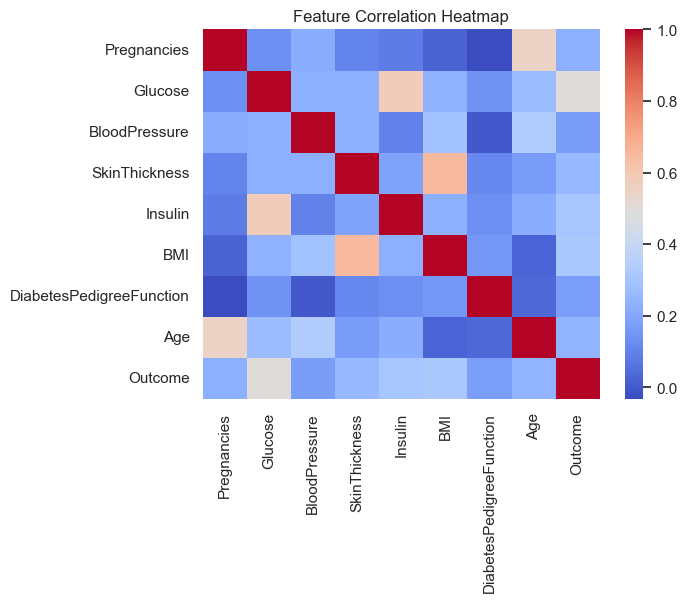

In [53]:
sns.heatmap(data = corr, cmap = "coolwarm")
plt.title("Feature Correlation Heatmap")

### 7.5 Pairplot for selected features.
Based on correlation analysis and earlier univariate exploration, the following features were selected for pairwise visual inspection due to their relatively stronger associations with the target variable and their representation of key metabolic and demographic domains: Glucose, BMI, Insulin, and Age.

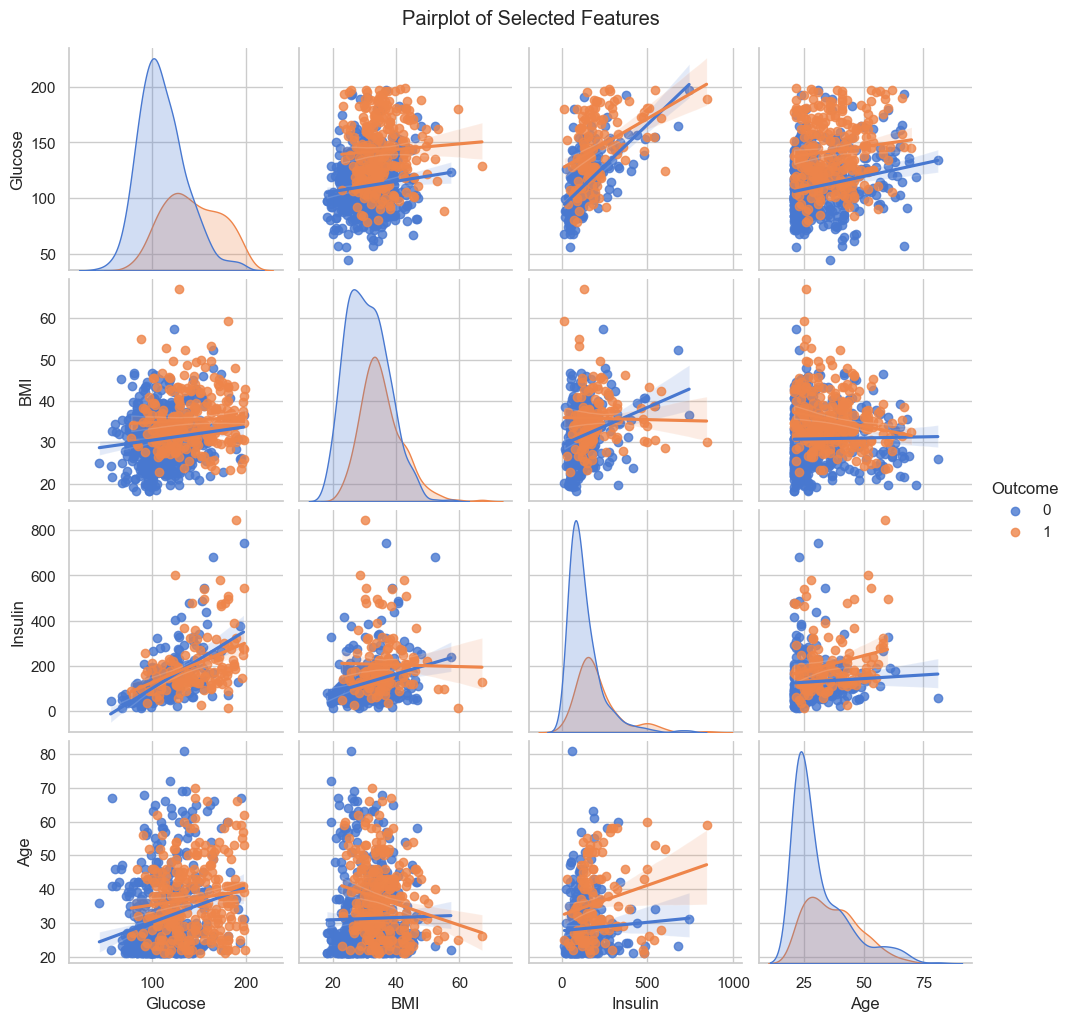

In [54]:
features = df[["Glucose", "BMI", "Insulin", "Age", "Outcome"]]
g = sns.pairplot(features, kind="reg", hue="Outcome")
g.fig.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

The pair plot kde shows partial separation between Outcome classes, most clearly along the Glucose axis, where diabetic individuals tend to cluster at higher values. However, substantial overlap remains across most feature pairs, indicating that no single feature fully separates the classes

Glucose and BMI show a weak upward trend, consistent with previously observed positive correlation values, but the relationship is not strongly linear

BMI and Insulin display a slight positive trend, suggesting weak-to-moderate interaction, but with high variability across both outcome groups

Despite observable trends, there is significant overlap between outcome classes across all feature pairs, indicating that the dataset is not linearly separable and will likely require non-linear models for optimal performance

Overall, the pair plot reveals partial class separation, most notably along Glucose, where the higher values are more frequently associated with Outcome = 1. However, significant overlap persists across all feature combinations, indicating that linear separability is limited. Relationships between variables are generally weak-to-moderate and consistent with earlier correlation analysis, particularly for Glucose–BMI and BMI–Insulin interactions. Overall, the dataset exhibits overlapping class structure, suggesting that predictive performance will likely depend on multivariate and potentially non-linear modelling approaches.

### Conclusion / Summary of EDA Findings

1. Several biologically impossible zeros were identified in variables such as Glucose, Insulin, BMI, Skin Thickness and Insulin, indicating possible missingness and leaving uncertainty on whether other plausible variables like Pregnancies are truly zero or also placeholders for missingness.
2. Insulin and Skin Thickness exhibited substantial missingness accounting for approximately 49% and 30% of the total observations respectively.
3. A structured missingness hierarchy was observed among Insulin, Skin Thickness, BMI and Blood Pressure.
4. Most variables displayed moderate to strong right skewness influenced by the presence of extreme values except Blood Pressure which displayed rough symmetry (weak right skew)
5. Multiple variables displayed rare but clinically plausible extreme values rather than obvious measurement errors.
6. Multiple observations displayed an outcome of 1 despite maximum Glucose levels (199) being below the clinical OGTT threshold for diabetes diagnosis (< 200)
7. No meaningful variable patterns were observed between the missingness subgroups created (skin_notna_insulin_na, skin_na_insulin_na and skin_notna_insulin_na)
8. Glucose displayed the strongest association with diabetes outcome.
9. The missingness subgroups did not display any meaningful associations with outcome.
10. Strong correlations were observed between BMI and Skin Thickness with moderate correlations between Insulin and Glucose, as well as Age and Pregnancies
11. The dataset will require further preprocessing steps such as scaling, and skewness handling.

#### Saving the cleaned dataset

In [55]:
df.to_csv("../data/diabetes_cleaned.csv", index = False)